# Rank-Based Visibility Evaluator

This notebook evaluates the four rank-based visibility conditions across visibility probability and produces only the six unified figures requested:

1. Rank, one aggregate line.
2. Rank, G as sender versus S as sender.
3. Rank, four directional conditions: GG, GS, SG, SS.
4. Diversity, one aggregate line.
5. Diversity, G as sender versus S as sender.
6. Diversity, four directional conditions: GG, GS, SG, SS.

All plotted values are averaged across K. The loader is interval-aware and matches the current running-script filename pattern.


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pickle
from pathlib import Path

legend_properties = {"weight": "bold"}

# =========================
# Configuration
# =========================
# Change this path to the folder that contains the saved pickle outputs.
result_folder = Path(r"/Volumes/T7/data/gst-0112-26/Performance_ranked_2")

agent_num = 200

# This follows the current running script's default interval setting.
visibility_interval = 10

# This list follows the current rank-based visibility running script.
# The value is the proportion of sender agents whose solutions are structurally visible.
visibility_prob_list = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5,
                        0.6, 0.7, 0.8, 0.9, 1.0]

prefixes = ["gg", "gs", "sg", "ss"]
condition_labels = {
    "gg": "G → G",
    "gs": "G → S",
    "sg": "S → G",
    "ss": "S → S",
}

# Only these two DVs are needed for the six requested figures.
dv_labels = {
    "breakthrough_rank": "Best solution rank",
    "diversity": "Diversity",
}

# Black-and-white line styles for publication-friendly figures.
four_line_styles = {
    "gg": {"marker": "o", "linestyle": "-",  "label": "G → G"},
    "gs": {"marker": "s", "linestyle": "--", "label": "G → S"},
    "sg": {"marker": "v", "linestyle": "-.", "label": "S → G"},
    "ss": {"marker": "^", "linestyle": ":",  "label": "S → S"},
}

sender_styles = {
    "G": {"marker": "o", "linestyle": "-",  "label": "G as sender"},
    "S": {"marker": "v", "linestyle": "--", "label": "S as sender"},
}


In [4]:
# =========================
# Load results
# =========================
def load_pickle(path):
    with open(path, "rb") as infile:
        return pickle.load(infile)


def result_file(prefix, visibility_prob, dv):
    """Return the expected result path for the current rank-based visibility scripts."""
    return result_folder / (
        f"{prefix}_rank_based_visibility_prob_{visibility_prob}_"
        f"interval_{visibility_interval}_{dv}_across_K_size_{agent_num}"
    )


def legacy_result_file(prefix, visibility_prob, dv):
    """Fallback path for older rank-based scripts that used a shorter filename."""
    return result_folder / f"{prefix}_visibility_prob_{visibility_prob}_{dv}_across_K_size_{agent_num}"


def resolve_result_file(prefix, visibility_prob, dv):
    path = result_file(prefix, visibility_prob, dv)
    if path.exists():
        return path

    legacy_path = legacy_result_file(prefix, visibility_prob, dv)
    if legacy_path.exists():
        return legacy_path

    return path


def diagnose_folder():
    print("Result folder:", result_folder)
    print("Folder exists:", result_folder.exists())

    available_files = sorted([p.name for p in result_folder.iterdir()]) if result_folder.exists() else []
    print("Number of files in folder:", len(available_files))
    print("First 10 files:")
    for name in available_files[:10]:
        print("  ", name)


def load_rank_visibility_results(prefixes=prefixes, strict=True):
    """Load rank-based visibility-probability results into data[prefix][dv].

    Each data[prefix][dv] array has shape:
        visibility probability × K

    The plotting cells below average across K, so they are robust to whether
    the running scripts use K=[0,...,8] or K=[1,...,8], as long as each file
    has a consistent K dimension.

    The loader first looks for the current filename, for example:
        gg_rank_based_visibility_prob_0.1_interval_10_breakthrough_rank_across_K_size_200

    It also supports older filenames without interval/rank_based as fallbacks.
    """
    data = {}
    missing_files = []

    for prefix in prefixes:
        data[prefix] = {}

        for dv in dv_labels:
            rows = []

            for visibility_prob in visibility_prob_list:
                path = resolve_result_file(prefix, visibility_prob, dv)

                if not path.exists():
                    missing_files.append(path)
                    continue

                values = np.asarray(load_pickle(path), dtype=float)
                rows.append(values)

            if rows:
                data[prefix][dv] = np.vstack(rows)

    if missing_files:
        print("\nMissing files:")
        for path in missing_files[:30]:
            print("  -", path.name)

        if len(missing_files) > 30:
            print(f"  ... and {len(missing_files) - 30} more")

        print("\nPossible causes:")
        print("1. result_folder is not the folder where the scripts saved outputs.")
        print("2. Some scripts have not finished.")
        print("3. agent_num differs from the saved filenames.")
        print("4. visibility_prob_list differs from the generated visibility-probability values.")
        print("5. visibility_interval differs from the saved filenames.")
        print("6. File prefix is different, e.g., gg/gs/sg/ss.")

        if strict:
            raise FileNotFoundError("Some expected result files are missing.")

    return data


diagnose_folder()
data = load_rank_visibility_results(strict=True)

print("\nLoaded data shapes:")
for prefix in prefixes:
    for dv in dv_labels:
        if dv in data[prefix]:
            print(prefix, dv, data[prefix][dv].shape)


Result folder: /Volumes/T7/data/gst-0112-26/Performance_ranked_2
Folder exists: True
Number of files in folder: 194
First 10 files:
   ._G_send_to_G_rank_visibility.py
   Crowd.py
   Evaluator_updated (3).ipynb
   G_send_to_G_rank_visibility.py
   G_send_to_S_rank_visibility.py
   Generalist.py
   Landscape.py
   S_send_to_G_rank_visibility.py
   S_send_to_S_rank_visibility.py
   Specialist.py

Loaded data shapes:
gg breakthrough_rank (11, 8)
gg diversity (11, 8)
gs breakthrough_rank (11, 8)
gs diversity (11, 8)
sg breakthrough_rank (11, 8)
sg diversity (11, 8)
ss breakthrough_rank (11, 8)
ss diversity (11, 8)


In [5]:
# =========================
# Plotting helpers
# =========================
def format_axis(ax, y_label, title, invert_y=False):
    for spine in ["left", "right", "top", "bottom"]:
        ax.spines[spine].set_linewidth(1.5)

    ax.set_xlabel("Visibility probability", fontweight="bold", fontsize=12)
    ax.set_ylabel(y_label, fontweight="bold", fontsize=12)
    ax.set_title(title, fontweight="bold", fontsize=13)
    ax.set_xticks(visibility_prob_list)
    ax.grid(alpha=0.25)

    if invert_y:
        ax.invert_yaxis()


def save_and_show(fig, filename):
    output_path = result_folder / filename
    fig.tight_layout()
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", output_path)


def mean_across_K(prefix, dv):
    return data[prefix][dv].mean(axis=1)


def overall_mean(dv):
    """Average across GG, GS, SG, SS and across K."""
    return np.mean([mean_across_K(prefix, dv) for prefix in prefixes], axis=0)


def sender_mean(sender, dv):
    """Average by sender type.

    G sender = average of GG and GS.
    S sender = average of SG and SS.
    """
    if sender == "G":
        selected = ["gg", "gs"]
    elif sender == "S":
        selected = ["sg", "ss"]
    else:
        raise ValueError("sender must be 'G' or 'S'.")

    return np.mean([mean_across_K(prefix, dv) for prefix in selected], axis=0)


def plot_one_line(dv, y_label, title, filename, invert_y=False):
    fig, ax = plt.subplots(figsize=(7.2, 5.0))
    ax.plot(
        visibility_prob_list, overall_mean(dv),
        color="black",
        linestyle="-",
        marker="o",
        linewidth=2.5,
        markersize=7,
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=1.5,
        label="Average across four conditions",
    )
    format_axis(ax, y_label=y_label, title=title, invert_y=invert_y)
    ax.legend(prop=legend_properties, frameon=False, loc="best")
    save_and_show(fig, filename)


def plot_sender_lines(dv, y_label, title, filename, invert_y=False):
    fig, ax = plt.subplots(figsize=(7.2, 5.0))

    for sender in ["G", "S"]:
        style = sender_styles[sender]
        ax.plot(
            visibility_prob_list, sender_mean(sender, dv),
            color="black",
            linestyle=style["linestyle"],
            marker=style["marker"],
            linewidth=2.5,
            markersize=7,
            markerfacecolor="white",
            markeredgecolor="black",
            markeredgewidth=1.5,
            label=style["label"],
        )

    format_axis(ax, y_label=y_label, title=title, invert_y=invert_y)
    ax.legend(prop=legend_properties, frameon=False, loc="best")
    save_and_show(fig, filename)


def plot_four_lines(dv, y_label, title, filename, invert_y=False):
    fig, ax = plt.subplots(figsize=(7.2, 5.0))

    for prefix in prefixes:
        style = four_line_styles[prefix]
        ax.plot(
            visibility_prob_list, mean_across_K(prefix, dv),
            color="black",
            linestyle=style["linestyle"],
            marker=style["marker"],
            linewidth=2.5,
            markersize=7,
            markerfacecolor="white",
            markeredgecolor="black",
            markeredgewidth=1.5,
            label=style["label"],
        )

    format_axis(ax, y_label=y_label, title=title, invert_y=invert_y)
    ax.legend(prop=legend_properties, frameon=False, loc="best")
    save_and_show(fig, filename)


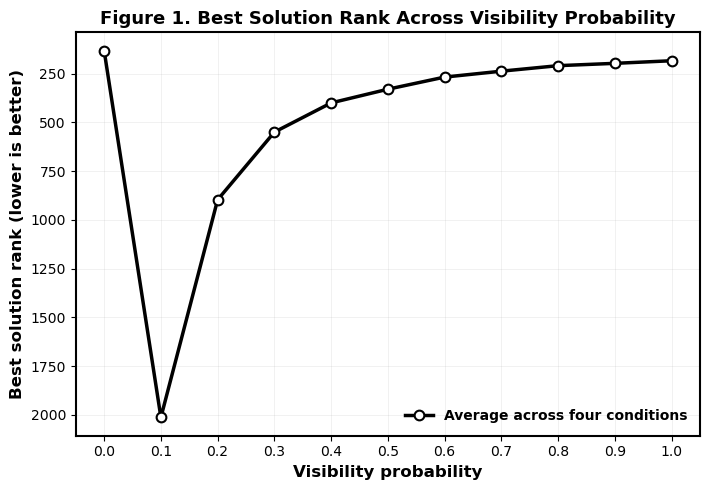

Saved: /Volumes/T7/data/gst-0112-26/Performance_ranked_2/figure_1_rank_one_line.png


In [6]:
# =========================
# Figure 1: One line — Rank across visibility probability
# =========================
plot_one_line(
    dv="breakthrough_rank",
    y_label="Best solution rank (lower is better)",
    title="Figure 1. Best Solution Rank Across Visibility Probability",
    filename="figure_1_rank_one_line.png",
    invert_y=True,
)

# **Interpretation.** Figure 1 shows that performance-ranked visibility does not reproduce the beneficial effect observed in the baseline visibility design. When visibility is absent, the average best rank is relatively strong. Once a small amount of performance-ranked visibility is introduced, the best solution rank worsens sharply, indicating that even limited exposure to externally high-performing solutions can disrupt the receiver crowd’s search process. Although performance gradually recovers as visibility probability increases, the overall pattern suggests that rank-weighted direct imitation is less effective than the baseline mechanism. (Under performance-ranked visibility, visibility strengths is to mitigate the loss of diversity in learning form the best-performing solutions)
#
# This contrast is theoretically important because the two visibility designs differ not only in *what* becomes visible, but also in *how* visible solutions are adopted. In the baseline model, receivers adopt visible solutions only when they perceive an improvement. This self-perceived improvement filter preserves local evaluative autonomy: visibility expands the set of candidate solutions, but adoption remains conditional on the receiver’s own knowledge representation. As a result, visibility tends to support search by injecting useful external variation without forcing convergence.
#
# By contrast, under performance-ranked visibility, receivers are more likely to imitate objectively high-performing sender solutions directly, regardless of whether the solution fits their own perceived search trajectory. This removes the receiver-side screening mechanism and turns visibility into a stronger form of social influence. The sharp deterioration at low nonzero visibility is consistent with a herding-like process: a small set of salient high-performing solutions attracts disproportionate attention, narrows subsequent search, and reduces the crowd’s ability to generate independent breakthrough paths. The partial recovery at higher visibility probabilities may occur because a larger visible pool provides more alternatives, reducing dependence on a few dominant sender solutions. However, because adoption remains externally ranked rather than internally filtered, the mechanism remains less effective than baseline visibility.


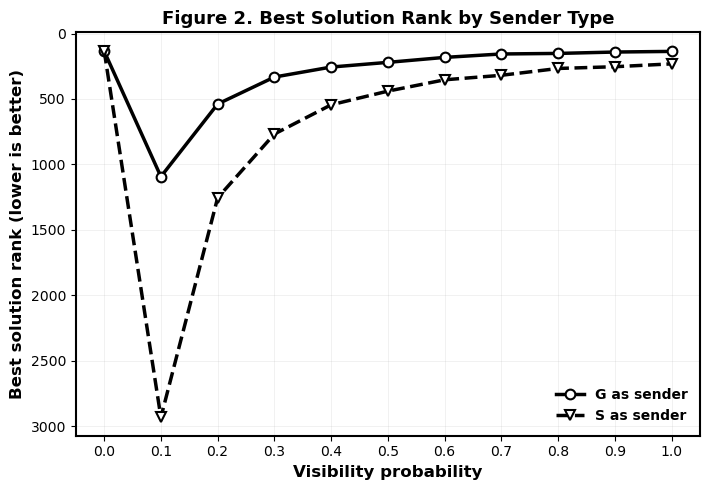

Saved: /Volumes/T7/data/gst-0112-26/Performance_ranked_2/figure_2_rank_sender_type.png


In [7]:
# =========================
# Figure 2: Two lines — Rank by sender type
# =========================
plot_sender_lines(
    dv="breakthrough_rank",
    y_label="Best solution rank (lower is better)",
    title="Figure 2. Best Solution Rank by Sender Type",
    filename="figure_2_rank_sender_type.png",
    invert_y=True,
)


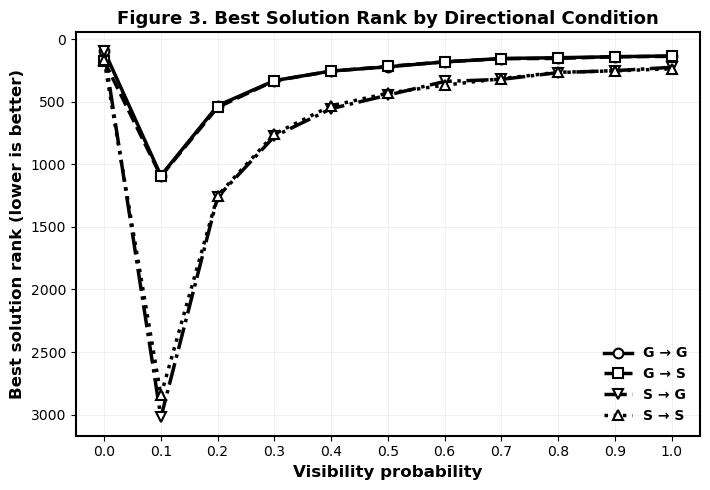

Saved: /Volumes/T7/data/gst-0112-26/Performance_ranked_2/figure_3_rank_four_conditions.png


In [8]:
# =========================
# Figure 3: Four lines — Rank by directional condition
# =========================
plot_four_lines(
    dv="breakthrough_rank",
    y_label="Best solution rank (lower is better)",
    title="Figure 3. Best Solution Rank by Directional Condition",
    filename="figure_3_rank_four_conditions.png",
    invert_y=True,
)


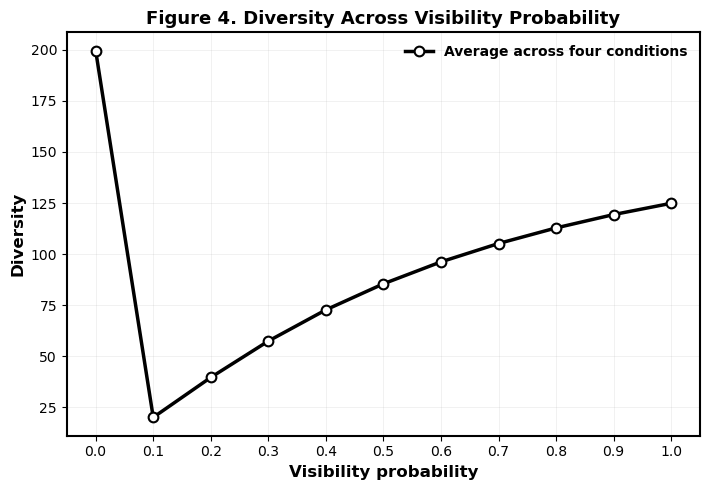

Saved: /Volumes/T7/data/gst-0112-26/Performance_ranked_2/figure_4_diversity_one_line.png


In [9]:
# =========================
# Figure 4: One line — Diversity across visibility probability
# =========================
plot_one_line(
    dv="diversity",
    y_label="Diversity",
    title="Figure 4. Diversity Across Visibility Probability",
    filename="figure_4_diversity_one_line.png",
    invert_y=False,
)


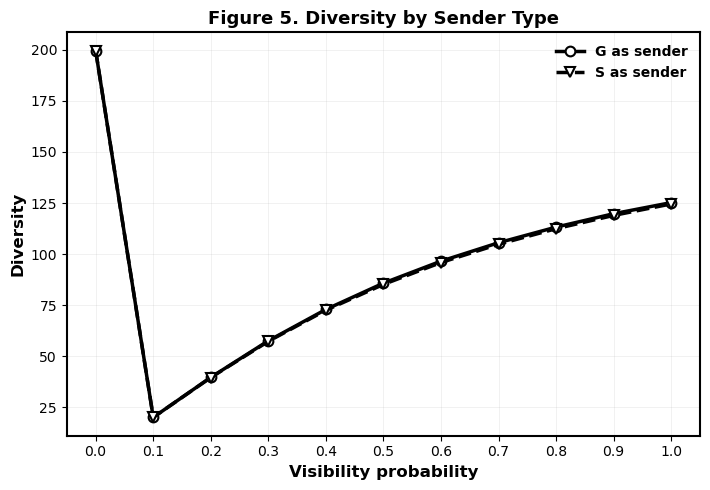

Saved: /Volumes/T7/data/gst-0112-26/Performance_ranked_2/figure_5_diversity_sender_type.png


In [10]:
# =========================
# Figure 5: Two lines — Diversity by sender type
# =========================
plot_sender_lines(
    dv="diversity",
    y_label="Diversity",
    title="Figure 5. Diversity by Sender Type",
    filename="figure_5_diversity_sender_type.png",
    invert_y=False,
)


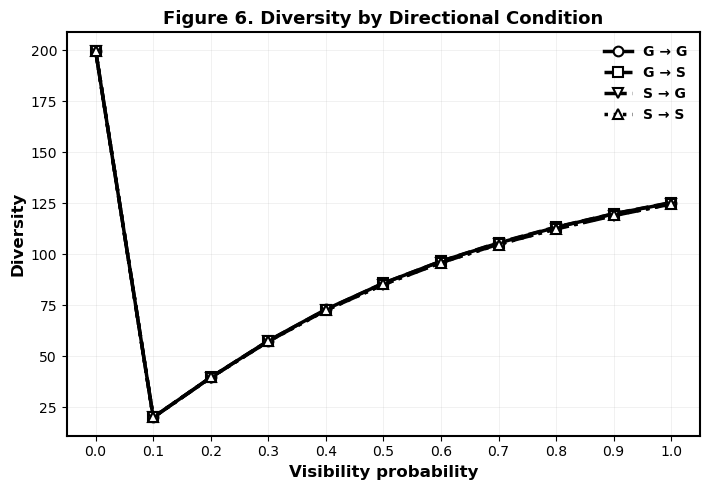

Saved: /Volumes/T7/data/gst-0112-26/Performance_ranked_2/figure_6_diversity_four_conditions.png


In [11]:
# =========================
# Figure 6: Four lines — Diversity by directional condition
# =========================
plot_four_lines(
    dv="diversity",
    y_label="Diversity",
    title="Figure 6. Diversity by Directional Condition",
    filename="figure_6_diversity_four_conditions.png",
    invert_y=False,
)


In [12]:
# =========================
# Optional helper: inspect exact plotted values as tables
# =========================
def visibility_prob_table(dv="breakthrough_rank"):
    """Return the values used in the one-line, sender-type, and four-condition figures."""
    table = {
        "overall": overall_mean(dv).round(4).tolist(),
        "G_sender": sender_mean("G", dv).round(4).tolist(),
        "S_sender": sender_mean("S", dv).round(4).tolist(),
    }
    for prefix in prefixes:
        table[prefix] = mean_across_K(prefix, dv).round(4).tolist()

    columns = [f"visibility_prob={value}" for value in visibility_prob_list]
    return table, columns


rank_table, columns = visibility_prob_table("breakthrough_rank")
diversity_table, _ = visibility_prob_table("diversity")

print("Columns:")
print(columns)
print("\nRank table:")
for key, values in rank_table.items():
    print(key, values)

print("\nDiversity table:")
for key, values in diversity_table.items():
    print(key, values)


Columns:
['visibility_prob=0.0', 'visibility_prob=0.1', 'visibility_prob=0.2', 'visibility_prob=0.3', 'visibility_prob=0.4', 'visibility_prob=0.5', 'visibility_prob=0.6', 'visibility_prob=0.7', 'visibility_prob=0.8', 'visibility_prob=0.9', 'visibility_prob=1.0']

Rank table:
overall [132.343, 2013.5784, 897.0536, 550.1275, 400.2625, 330.0609, 267.8256, 237.5294, 209.2711, 197.3553, 184.0027]
G_sender [133.8828, 1093.5672, 538.6875, 332.5094, 255.9716, 220.1397, 182.2166, 156.0709, 151.8388, 141.2619, 136.3922]
S_sender [130.8031, 2933.5897, 1255.4197, 767.7456, 544.5534, 439.9822, 353.4347, 318.9878, 266.7034, 253.4487, 231.6131]
gg [93.26, 1091.28, 531.8688, 332.2169, 255.4569, 221.7769, 182.575, 155.5381, 148.8563, 141.4081, 134.4662]
gs [174.5056, 1095.8544, 545.5062, 332.8019, 256.4862, 218.5025, 181.8581, 156.6038, 154.8213, 141.1156, 138.3181]
sg [92.8156, 3021.6875, 1260.6756, 777.135, 555.91, 447.7844, 338.7581, 321.89, 268.15, 252.5056, 225.7881]
ss [168.7906, 2845.4919, 1250.